In [3]:
import numpy as np
import pandas as pd


In [4]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [22]:
df = pd.read_csv("heart.csv")
X = df.drop('target', axis=1)
y = df['target']


# Divide into test set and train set

In [10]:
from sklearn.model_selection import train_test_split 

train_set, test_set = train_test_split(
   df, test_size=0.2, stratify=df["target"], random_state=42)

X_train = train_set.drop("target", axis=1)
y_train = train_set["target"].copy()

X_test = test_set.drop("target", axis=1)
y_test = test_set["target"].copy()

# Continue analyzing the data

In [11]:
#Check if there are heavy-tailed data
from scipy.stats import skew

numeric_cols = train_set.select_dtypes(include=np.number).columns
skewed_feats = train_set[numeric_cols].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

print("Skew of numerical features:")
print(skewed_feats)

skewed_features = skewed_feats[skewed_feats > 0.8].index.tolist()
print("High skew features:", skewed_features)

skewed_features = [col for col in skewed_features if col in X_train.columns]


Skew of numerical features:
fbs         1.920805
oldpeak     1.263073
ca          1.245629
chol        0.938036
trestbps    0.764765
exang       0.674374
cp          0.560258
restecg     0.196455
target     -0.053678
age        -0.271297
thal       -0.460502
slope      -0.473870
thalach    -0.491578
sex        -0.847701
dtype: float64
High skew features: ['fbs', 'oldpeak', 'ca', 'chol']


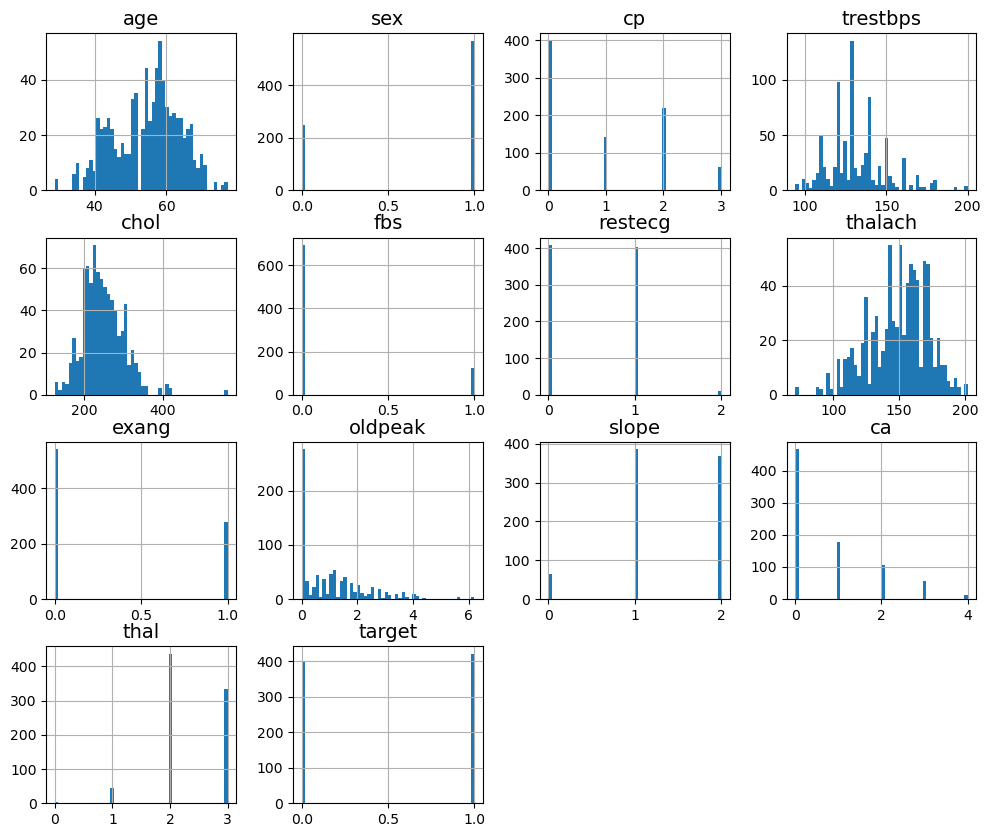

In [12]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

train_set.hist(bins=50, figsize=(12, 10))
plt.show()


# train a decision tree classifier

from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train model
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

# Plot tree
plt.figure(figsize=(20, 10))
plot_tree(dtree, feature_names=df.columns[:-1], class_names=["No Disease", "Disease"], filled=True)
plt.show()

## Analyze Overfitting and Control Depth

In [18]:
# Check accuracy
train_acc = dtree.score(X_train, y_train)
test_acc = dtree.score(X_test, y_test)
print(f"Train Accuracy: {train_acc:.2f}, Test Accuracy: {test_acc:.2f}")

# Limit max depth
dtree_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree_limited.fit(X_train, y_train)
print("Limited Depth Test Accuracy:", dtree_limited.score(X_test, y_test))

Train Accuracy: 1.00, Test Accuracy: 0.99
Limited Depth Test Accuracy: 0.8536585365853658


## Train a Random Forest and Compare Accuracy

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Compare accuracy
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 1.0


## Interpret Feature Importances

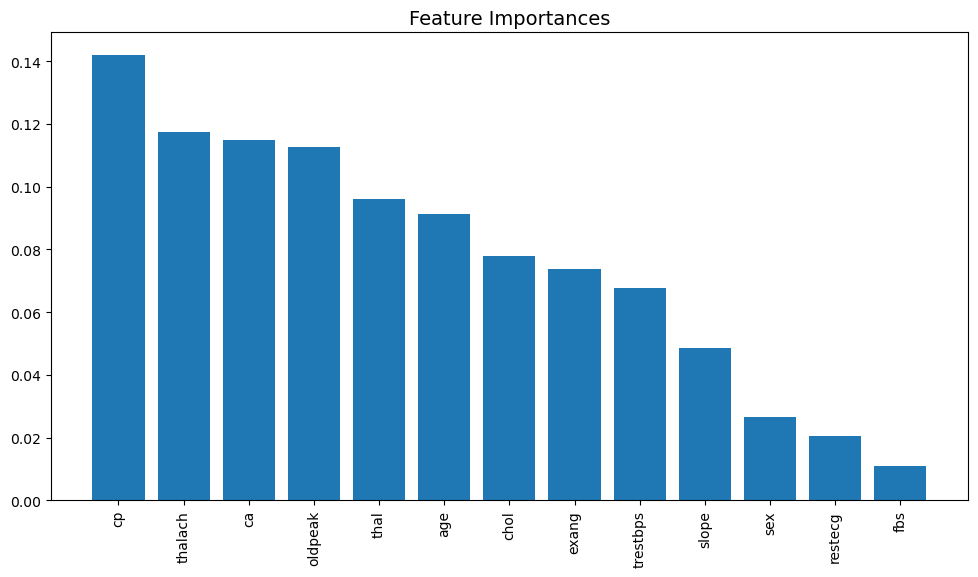

In [23]:
# Feature importance plot
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

## Evaluate Using Cross-Validation

In [24]:
from sklearn.model_selection import cross_val_score

cv_scores_dtree = cross_val_score(dtree, X, y, cv=5)
cv_scores_rf = cross_val_score(rf, X, y, cv=5)

print("Decision Tree CV Accuracy:", cv_scores_dtree.mean())
print("Random Forest CV Accuracy:", cv_scores_rf.mean())

Decision Tree CV Accuracy: 1.0
Random Forest CV Accuracy: 0.9970731707317073
